In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from geodesiq import ControlModel, about

In [6]:
def H_fun(x, z):
    return np.array([[z, 1j * x], [-1j * x, -z]])


def H_partial(x, z):
    return np.array([[0, 1j], [-1j, 0]])


alpha = 1
beta = 1
z = 1
x0 = -10

# model = ControlModel(H_fun, partial_H_func=H_partial)
model = ControlModel(H_fun)
model.set_parameters(z=z)
model.set_control(control_name='x', pulse_initial=x0, pulse_final=-x0, initial_state=0, alpha=alpha, beta=beta)
model.solve_problem(pulse_accuracy=int(1e6))

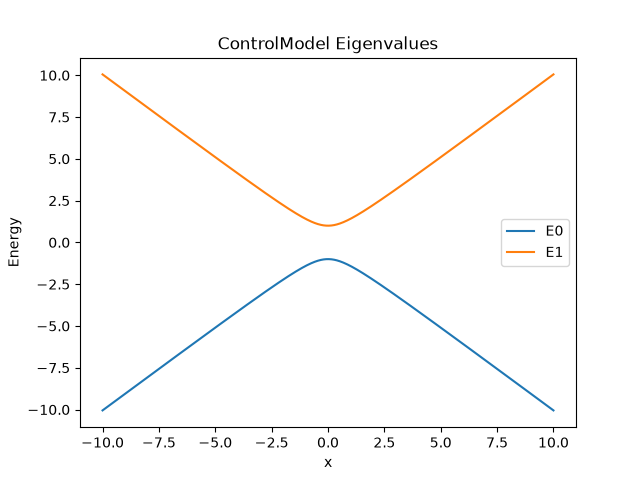

In [7]:
model.plot_eigenvalues();

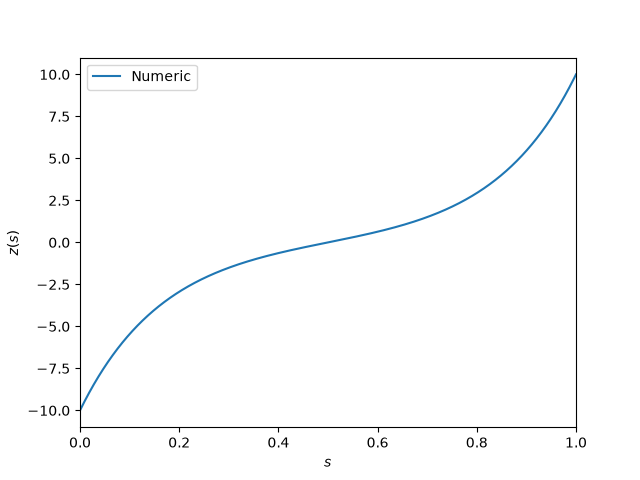

In [8]:
s, pulse = model._s, model.control_sol

fig, ax = plt.subplots()
ax.plot(s, pulse, label='Numeric')

ax.legend()
ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$z(s)$')
ax.set_xlim(0, 1);